# AdaBoost

В этом ноутбуке посмотрим:
- как слабые модели складываются в сильную
- как растут веса ошибочных объектов
- влияние `n_estimators` (количество деревьев)
- метрики: Accuracy, Precision, Recall, F1, ROC-AUC

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay)

np.random.seed(42)
plt.rcParams['figure.dpi'] = 90

## 1. Данные
Берём двумерный датасет `make_moons`.

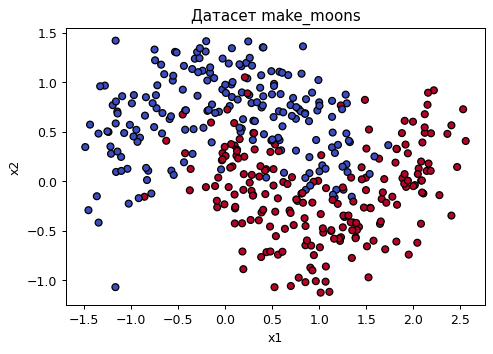

In [2]:
X, y = make_moons(n_samples=400, noise=0.30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=30)
plt.title('Датасет make_moons')
plt.xlabel('x1'); plt.ylabel('x2')
plt.show()

## 2. Слабая модель: `DecisionTreeClassifier`
Наше дерево — одно разбиение по одной фиче. На сложных данных он работает плохо.

In [3]:
stump = DecisionTreeClassifier(max_depth=1, random_state=42)
stump.fit(X_train, y_train)
print(f'Accuracy одного дерева: {stump.score(X_test, y_test):.3f}')

Accuracy одного дерева: 0.800


## 3. AdaBoost: деревце + деревце + ... = сильная модель

In [4]:
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)
ada.fit(X_train, y_train)
print(f'Accuracy AdaBoost (100 деревьев): {ada.score(X_test, y_test):.3f}')

Accuracy AdaBoost (100 деревьев): 0.917


## 4. Decision boundary: одно дерево - DecisionTreeClassifier vs AdaBoost

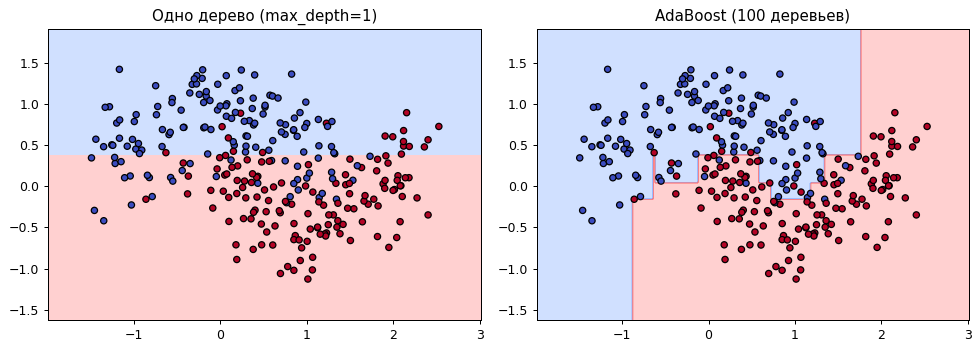

In [5]:
def plot_boundary(model, X, y, ax, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['#6699ff', '#ff6666']))
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=25)
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_boundary(stump, X_train, y_train, axes[0], 'Одно дерево (max_depth=1)')
plot_boundary(ada,   X_train, y_train, axes[1], 'AdaBoost (100 деревьев)')
plt.tight_layout(); plt.show()

## 5. Как AdaBoost увеличивает веса ошибочных объектов

Реализуем несколько шагов AdaBoost вручную, чтобы увидеть рост весов на ошибках. После каждой итерации точки с ошибкой становятся «крупнее» — алгоритм даёт им больший вес.

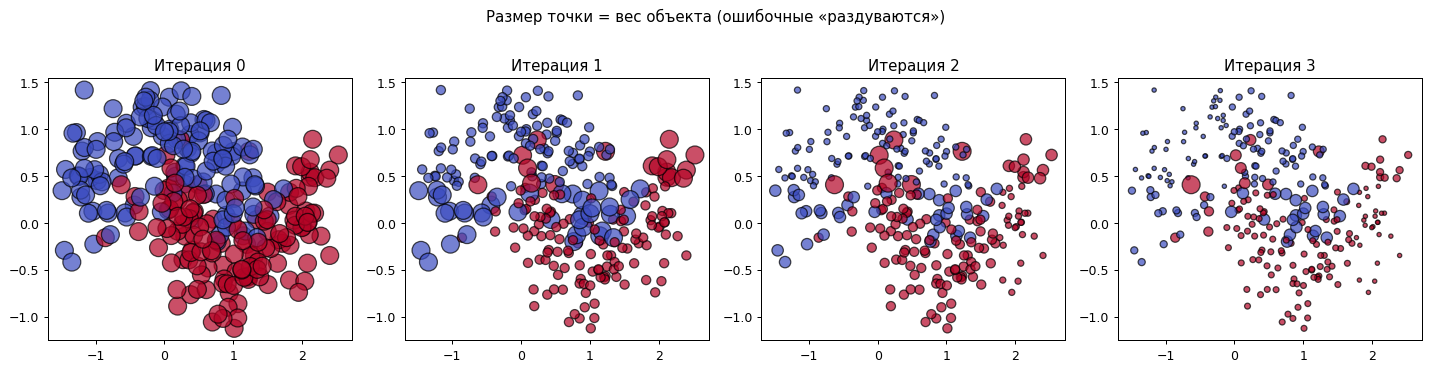

In [6]:
def adaboost_steps(X, y, n_steps=4):
    n = len(y)
    w = np.ones(n) / n
    weights_history = [w.copy()]
    y_signed = np.where(y == 1, 1, -1)
    for _ in range(n_steps):
        clf = DecisionTreeClassifier(max_depth=1)
        clf.fit(X, y, sample_weight=w)
        pred = np.where(clf.predict(X) == 1, 1, -1)
        err = np.sum(w * (pred != y_signed)) / np.sum(w)
        err = np.clip(err, 1e-10, 1 - 1e-10)
        alpha = 0.5 * np.log((1 - err) / err)
        w = w * np.exp(-alpha * y_signed * pred)
        w /= w.sum()
        weights_history.append(w.copy())
    return weights_history

history = adaboost_steps(X_train, y_train, n_steps=3)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, (ax, w) in enumerate(zip(axes, history)):
    sizes = w / w.max() * 200 + 5
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train,
               cmap='coolwarm', s=sizes, edgecolor='k', alpha=0.7)
    ax.set_title(f'Итерация {i}')
plt.suptitle('Размер точки = вес объекта (ошибочные «раздуваются»)', y=1.02)
plt.tight_layout(); plt.show()

## 6. Влияние `n_estimators` на качество

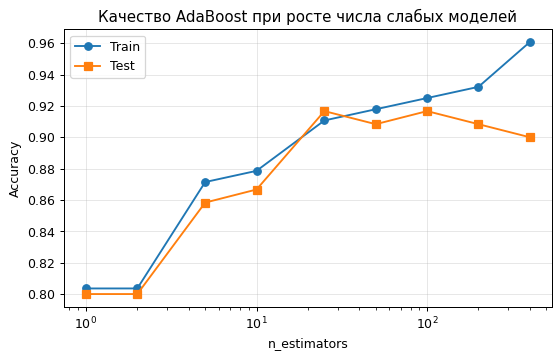

In [7]:
n_list = [1, 2, 5, 10, 25, 50, 100, 200, 400]
train_acc, test_acc = [], []

for n in n_list:
    m = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=n, random_state=42
    ).fit(X_train, y_train)
    train_acc.append(m.score(X_train, y_train))
    test_acc.append(m.score(X_test, y_test))

plt.figure(figsize=(7, 4))
plt.plot(n_list, train_acc, 'o-', label='Train')
plt.plot(n_list, test_acc,  's-', label='Test')
plt.xscale('log')
plt.xlabel('n_estimators'); plt.ylabel('Accuracy')
plt.title('Качество AdaBoost при росте числа слабых моделей')
plt.grid(alpha=0.3); plt.legend(); plt.show()

## 7. Метрики финальной модели

In [8]:
y_pred  = ada.predict(X_test)
y_proba = ada.predict_proba(X_test)[:, 1]

metrics = {
    'Accuracy':  accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall':    recall_score(y_test, y_pred),
    'F1-score':  f1_score(y_test, y_pred),
    'ROC-AUC':   roc_auc_score(y_test, y_proba),
}
pd.DataFrame(metrics, index=['AdaBoost']).round(3)

,Accuracy,Precision,Recall,F1-score,ROC-AUC
AdaBoost,0.917,0.963,0.867,0.912,0.954


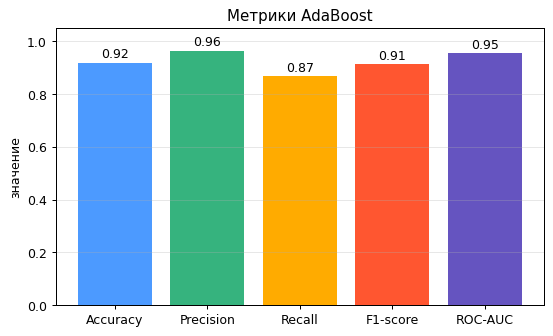

In [9]:
plt.figure(figsize=(7, 4))
bars = plt.bar(metrics.keys(), metrics.values(),
               color=['#4C9AFF', '#36B37E', '#FFAB00', '#FF5630', '#6554C0'])
plt.ylim(0, 1.05)
for b, v in zip(bars, metrics.values()):
    plt.text(b.get_x() + b.get_width()/2, v + 0.02, f'{v:.2f}', ha='center')
plt.title('Метрики AdaBoost'); plt.ylabel('значение')
plt.grid(axis='y', alpha=0.3); plt.show()

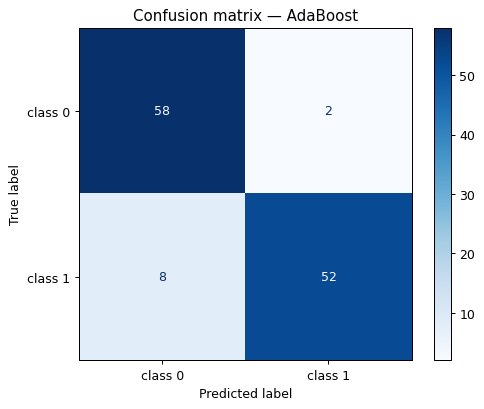

In [10]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['class 0', 'class 1']).plot(cmap='Blues')
plt.title('Confusion matrix — AdaBoost'); plt.show()

#**Общий итог:**

- Одно `DecisionTreeClassifier` (дерево) строит лишь одну прямую — слабая модель.
- AdaBoost складывает множество таких деревьев и получает гибкую границу решения.
- Веса ошибочных объектов растут на каждой итерации — следующее дерево концентрируется на них.
- С ростом `n_estimators` (количество деревьев) качество растёт, но после некоторого порога выходит на плато (или начинается переобучение).
- На `make_moons` AdaBoost из 100 деревьев даёт высокие Accuracy / F1 / ROC-AUC.